# Fire Impact Assessment

## Table of Contents

1. [Import libraries](#1)<br>
2. [Read images](#2)<br>
3. [Subset](#3)<br>
    
</div>
<hr>

## 1. Import libraries

In [2]:
# Import necessary packages
import os

from shapely.geometry import mapping
# Use geopandas for vector data and xarray for raster data
import geopandas as gpd
import xarray as xr
import rioxarray as rxr

import earthpy as et
import earthpy.spatial as es
import earthpy.plot as ep

import os
import sys
from glob import glob

import matplotlib.pyplot as plt
%matplotlib inline

C:\Users\Wenge\miniforge3\envs\sds\Lib\site-packages\earthpy\__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


## 2. Open and read the polygon of the Jennings Creek Fire

In [3]:
# use an approximated fire polygon 
os.chdir(r'C:\Users\Wenge\Dropbox (Hunter College)\Teaching\GTECH\331&731\2025F_331&731\data\JenningsCreekFire')
print(os.getcwd())
firepoly = gpd.read_file('jennings_creek_wildfire.geojson')
firepoly.crs

C:\Users\Wenge\Dropbox (Hunter College)\Teaching\GTECH\331&731\2025F_331&731\data\JenningsCreekFire


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
firepoly = firepoly.to_crs(32618)

In [5]:
firepoly.crs

<Projected CRS: EPSG:32618>
Name: WGS 84 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 78°W and 72°W, northern hemisphere between equator and 84°N, onshore and offshore. Bahamas. Canada - Nunavut; Ontario; Quebec. Colombia. Cuba. Ecuador. Greenland. Haiti. Jamaica. Panama. Turks and Caicos Islands. United States (USA). Venezuela.
- bounds: (-78.0, 0.0, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
firepoly.explore()

## Read NYC temperature data

In [3]:
# need a NYC image
os.chdir(r'C:\Users\Wenge\Dropbox (Hunter College)\Teaching\GTECH\331&731\2025F_331&731\data\LC09_L2SP_014031_20240826_20240827_02_T1')
print(os.getcwd())
cwd = os.getcwd()
# Get all surface reflectance bands 
fp = glob(os.path.join(cwd,'*ST_B10*.tif'))
print(fp[0])
#print(fp[4])

tsurf = rxr.open_rasterio(fp[0], masked=True)
#red.rio.write_crs("EPSG:32618", inplace=True)

#tsurf_cl = tsurf.rio.clip(firepoly.geometry.apply(mapping), firepoly.crs )
#tsurf_cl.plot()

print(tsurf.rio.crs)
print(tsurf.rio.count)
print(tsurf.rio.width)
print(tsurf.rio.height)

C:\Users\Wenge\Dropbox (Hunter College)\Teaching\GTECH\331&731\2025F_331&731\data\LC09_L2SP_014031_20240826_20240827_02_T1
C:\Users\Wenge\Dropbox (Hunter College)\Teaching\GTECH\331&731\2025F_331&731\data\LC09_L2SP_014031_20240826_20240827_02_T1\LC09_L2SP_014031_20240826_20240827_02_T1_ST_B10.TIF
EPSG:32618
1
7731
7841


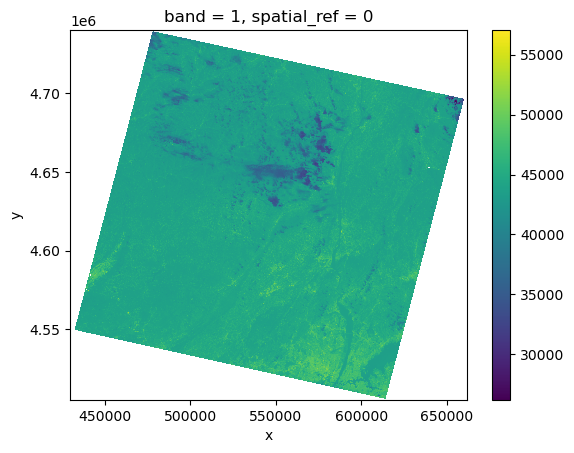

In [4]:
tsurf.plot()

C:\Users\Wenge\Dropbox (Hunter College)\Teaching\GTECH\331&731\2025F_331&731\data\LC08_L2SP_014031_20250704_20250714_02_T1
C:\Users\Wenge\Dropbox (Hunter College)\Teaching\GTECH\331&731\2025F_331&731\data\LC08_L2SP_014031_20250704_20250714_02_T1\LC08_L2SP_014031_20250704_20250714_02_T1_SR_B4.TIF
C:\Users\Wenge\Dropbox (Hunter College)\Teaching\GTECH\331&731\2025F_331&731\data\LC08_L2SP_014031_20250704_20250714_02_T1\LC08_L2SP_014031_20250704_20250714_02_T1_SR_B5.TIF
EPSG:32618
EPSG:32618
1
182
184
C:\Users\Wenge\Dropbox (Hunter College)\Teaching\GTECH\331&731\2025F_331&731\data\LC08_L2SP_014031_20250704_20250714_02_T1\LC08_L2SP_014031_20250704_20250714_02_T1_ST_B10.TIF
EPSG:32618


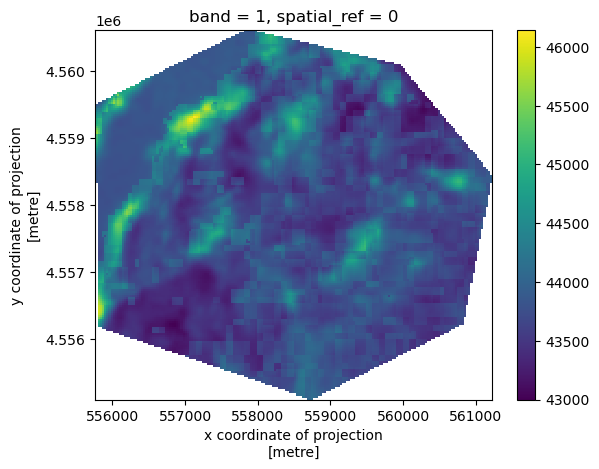

In [19]:
os.chdir(r'C:\Users\Wenge\Dropbox (Hunter College)\Teaching\GTECH\331&731\2025F_331&731\data\LC08_L2SP_014031_20250704_20250714_02_T1')
print(os.getcwd())
cwd = os.getcwd()
# Get all surface reflectance bands 
fp = glob(os.path.join(cwd,'*_B*.tif'))
print(fp[3])
print(fp[4])

red = rxr.open_rasterio(fp[3], masked=True)
nir = rxr.open_rasterio(fp[4], masked=True)
swir = rxr.open_rasterio(fp[6], masked=True)

print(red.rio.crs)

red_cl = red.rio.clip(firepoly.geometry.apply(mapping), firepoly.crs)
nir_cl = nir.rio.clip(firepoly.geometry.apply(mapping), firepoly.crs)
swir_cl = swir.rio.clip(firepoly.geometry.apply(mapping), firepoly.crs)

ndvi = (nir_cl - red_cl)/(nir_cl + red_cl)
#ndvi.plot()

print(tsurf.rio.crs)
print(tsurf_cl.rio.count)
print(tsurf_cl.rio.width)
print(tsurf_cl.rio.height)

fp = glob(os.path.join(cwd,'*ST_B10*.tif'))
print(fp[0])

tsurf = rxr.open_rasterio(fp[0], masked=True)
#red.rio.write_crs("EPSG:32618", inplace=True)
print(tsurf.rio.crs)

tsurf_cl = tsurf.rio.clip(firepoly.geometry.apply(mapping), firepoly.crs )
tsurf_cl.plot()
#plt.scatter(ndvi, tsurf)


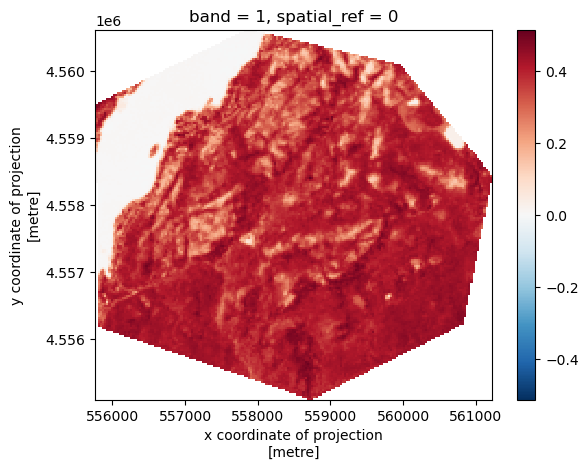

In [20]:
ndvi.plot()

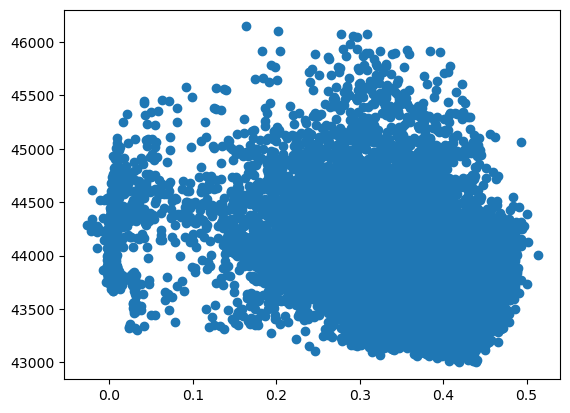

In [21]:
plt.scatter(ndvi.squeeze().values.flatten(), tsurf_cl.squeeze().values.flatten())

xarray.core.dataarray.DataArray